<a href="https://colab.research.google.com/github/planket01/2026_DL/blob/main/chapter05_fundamentals_of_ml%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [ ]:
!pip install keras keras-hub --upgrade -q

In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [ ]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Fundamentals of machine learning

### Generalization: The goal of machine learning

#### Underfitting and overfitting

##### Noisy training data

##### Ambiguous features

##### Rare features and spurious correlations

In [2]:
from keras.datasets import mnist
import numpy as np

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

train_images_with_noise_channels = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1
)

train_images_with_zeros_channels = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1
)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
train_images_with_noise_channels

array([[0.        , 0.        , 0.        , ..., 0.45600483, 0.6291386 ,
        0.93619766],
       [0.        , 0.        , 0.        , ..., 0.57415349, 0.49668154,
        0.11395008],
       [0.        , 0.        , 0.        , ..., 0.18256863, 0.14109717,
        0.40356323],
       ...,
       [0.        , 0.        , 0.        , ..., 0.6441203 , 0.03606976,
        0.25961481],
       [0.        , 0.        , 0.        , ..., 0.78704207, 0.9572363 ,
        0.33919226],
       [0.        , 0.        , 0.        , ..., 0.51672971, 0.13682618,
        0.02297178]])

In [4]:
import keras
from keras import layers

def get_model():
    model = keras.Sequential(
        [
            layers.Dense(512, activation="relu"),
            layers.Dense(10, activation="softmax"),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model
#_noise, _zero에 데이터가 저장됨
model = get_model()
history_noise = model.fit(
    train_images_with_noise_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

model = get_model()
history_zeros = model.fit(
    train_images_with_zeros_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8627 - loss: 0.4566 - val_accuracy: 0.9178 - val_loss: 0.2796
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9311 - loss: 0.2333 - val_accuracy: 0.9424 - val_loss: 0.1964
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9522 - loss: 0.1607 - val_accuracy: 0.9465 - val_loss: 0.1810
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9678 - loss: 0.1102 - val_accuracy: 0.9544 - val_loss: 0.1633
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9766 - loss: 0.0814 - val_accuracy: 0.9616 - val_loss: 0.1359
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9834 - loss: 0.0590 - val_accuracy: 0.9619 - val_loss: 0.1370
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9881 - loss: 0.0426 - val_accuracy: 0.9619 - val_loss: 0.1312
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9932 - loss: 0.0275 - val_accuracy: 0.

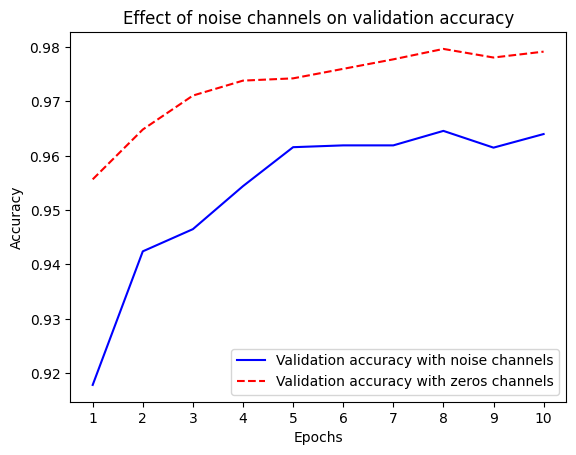

In [5]:
import matplotlib.pyplot as plt

val_acc_noise = history_noise.history["val_accuracy"]
val_acc_zeros = history_zeros.history["val_accuracy"]
epochs = range(1, 11)
plt.plot(
    epochs,
    val_acc_noise,
    "b-",
    label="Validation accuracy with noise channels",
)
plt.plot(
    epochs,
    val_acc_zeros,
    "r--",
    label="Validation accuracy with zeros channels",
)
plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9168 - loss: 0.2982 - val_accuracy: 0.9577 - val_loss: 0.1509
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9650 - loss: 0.1216 - val_accuracy: 0.9646 - val_loss: 0.1172
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9763 - loss: 0.0806 - val_accuracy: 0.9706 - val_loss: 0.0985
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9835 - loss: 0.0570 - val_accuracy: 0.9741 - val_loss: 0.0846
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9887 - loss: 0.0411 - val_accuracy: 0.9758 - val_loss: 0.0799
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9920 - loss: 0.0295 - val_accuracy: 0.9764 - val_loss: 0.0770
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9944 - loss: 0.0223 - val_accuracy: 0.9778 - val_loss: 0.0777
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9959 - loss: 0.0172 - val_accuracy: 0.

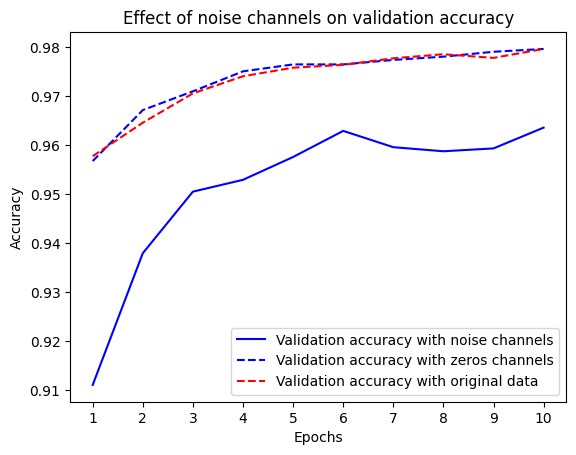

In [15]:
import matplotlib.pyplot as plt
import keras
from keras import layers

def get_model():
    model = keras.Sequential(
        [
            layers.Dense(512, activation="relu"),
            layers.Dense(10, activation="softmax"),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


# 3. Original MNIST 데이터 모델 학습 (추가)
model = get_model()
history_original = model.fit(
    train_images,  # 노이즈나 0을 추가하지 않은 원본 MNIST 데이터셋 변수명
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

# 4. 결과 시각화
val_acc_noise = history_noise.history["val_accuracy"]
val_acc_zeros = history_zeros.history["val_accuracy"]
val_acc_original = history_original.history["val_accuracy"]

epochs = range(1, 11)

plt.plot(
    epochs,
    val_acc_noise,
    "b-",
    label="Validation accuracy with noise channels",
)
plt.plot(
    epochs,
    val_acc_zeros,
    "b--",
    label="Validation accuracy with zeros channels",
)
plt.plot(
    epochs,
    val_acc_original,
    "r--",  # 이미지의 세 번째 선 스타일(점선) 반영
    label="Validation accuracy with original data",
)

plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

1. Validation accuracy with original data (빨간 점선)
의미: 아무런 가공을 하지 않은 순수한 원본 MNIST 숫자 데이터로 모델을 학습시켰을 때의 검증 정확도입니다.

특징: 기준점이 되는 성능(Baseline)입니다. 모델이 이미지의 실제 피처(선, 곡선 등)만 학습하므로 약 98% 수준의 가장 안정적이고 높은 성능을 보입니다.

2. Validation accuracy with zeros channels (파란 점선)
의미: 원본 이미지 옆에 모든 값이 '0'으로 채워진 쓸모없는 채널(데이터)을 덧붙여서 학습시켰을 때의 검증 정확도입니다.

특징: 원본 데이터(빨간 점선)와 거의 똑같은 높은 성능을 유지합니다.

이유: 입력값이 항상 0이기 때문에, 인공신경망은 해당 입력과 연결된 가중치(Weight)를 0으로 쉽게 수렴시켜 버립니다. 즉, "이 데이터는 아무 정보도 없으니 무시하라"는 것을 모델이 스스로 금방 찾아냅니다.

3. Validation accuracy with noise channels (파란 실선)
의미: 원본 이미지 옆에 무작위 난수(Noise)로 채워진 무의미한 채널을 덧붙여서 학습시켰을 때의 검증 정확도입니다.

특징: 다른 두 그래프에 비해 성능이 약 91%~96% 수준으로 현저히 떨어집니다.

이유: 무작위 노이즈는 매번 패턴이 바뀌기 때문에, 모델은 이 무의미한 노이즈 속에서도 억지로 정답과의 연관성(가짜 패턴)을 찾으려고 시도합니다. 결과적으로 필요 없는 노이즈 정보까지 외워버리는 과대적합(Overfitting)이 발생하여, 새로운 검증 데이터에서의 성능(일반화 능력)이 크게 떨어지게 됩니다.

#### The nature of generalization in deep learning

In [7]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

random_train_labels = train_labels[:]
np.random.shuffle(random_train_labels) #랜덤하게 셔플해서 한 것 <- 계속 반복해서 정확도를 높여줌

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images,
    random_train_labels,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1040 - loss: 2.3152 - val_accuracy: 0.1102 - val_loss: 2.3038
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1177 - loss: 2.2988 - val_accuracy: 0.1049 - val_loss: 2.3124
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1271 - loss: 2.2912 - val_accuracy: 0.1007 - val_loss: 2.3178
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1388 - loss: 2.2788 - val_accuracy: 0.0976 - val_loss: 2.3264
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1517 - loss: 2.2636 - val_accuracy: 0.1027 - val_loss: 2.3327
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1663 - loss: 2.2441 - val_accuracy: 0.1037 - val_loss: 2.3398
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1796 - loss: 2.2208 - val_accuracy: 0.1003 - val_loss: 2.3650
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1938 - loss: 2.1952 - val_accu

##### The manifold hypothesis

##### Interpolation as a source of generalization

##### Why deep learning works

##### Training data is paramount

### Evaluating machine-learning models

#### Training, validation, and test sets

##### Simple hold-out validation

##### K-fold validation

##### Iterated K-fold validation with shuffling

#### Beating a common-sense baseline

#### Things to keep in mind about model evaluation

### Improving model fit

#### Tuning key gradient descent parameters

In [8]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1026 - loss: 14.4332 - val_accuracy: 0.0997 - val_loss: 14.5117
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0992 - loss: 14.5191 - val_accuracy: 0.0997 - val_loss: 14.5117
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0992 - loss: 14.5190 - val_accuracy: 0.0997 - val_loss: 14.5117
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0992 - loss: 14.5190 - val_accuracy: 0.0997 - val_loss: 14.5117
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0992 - loss: 14.5190 - val_accuracy: 0.0997 - val_loss: 14.5117
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0992 - loss: 14.5190 - val_accuracy: 0.0997 - val_loss: 14.5117
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0992 - loss: 14.5190 - val_accuracy: 0.0997 - val_loss: 14.5117
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0992 - loss: 14.5190 - v

In [9]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-2),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9026 - loss: 0.5276 - val_accuracy: 0.9569 - val_loss: 0.1525
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9649 - loss: 0.1281 - val_accuracy: 0.9642 - val_loss: 0.1417
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9732 - loss: 0.1012 - val_accuracy: 0.9623 - val_loss: 0.1673
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9787 - loss: 0.0873 - val_accuracy: 0.9650 - val_loss: 0.1841
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9815 - loss: 0.0735 - val_accuracy: 0.9728 - val_loss: 0.1664
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9851 - loss: 0.0609 - val_accuracy: 0.9707 - val_loss: 0.1885
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9872 - loss: 0.0566 - val_accuracy: 0.9721 - val_loss: 0.1647
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9882 - loss: 0.0539 - val_accuracy: 0.

#### Using better architecture priors

#### Increasing model capacity

In [10]:
model = keras.Sequential([layers.Dense(10, activation="softmax")])
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_small_model = model.fit(
    train_images, train_labels, epochs=20, batch_size=128, validation_split=0.2
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8346 - loss: 0.6661 - val_accuracy: 0.8999 - val_loss: 0.3633
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9031 - loss: 0.3529 - val_accuracy: 0.9137 - val_loss: 0.3115
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9124 - loss: 0.3178 - val_accuracy: 0.9185 - val_loss: 0.2933
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9155 - loss: 0.3017 - val_accuracy: 0.9203 - val_loss: 0.2844
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9181 - loss: 0.2919 - val_accuracy: 0.9221 - val_loss: 0.2790
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9197 - loss: 0.2850 - val_accuracy: 0.9249 - val_loss: 0.2747
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9219 - loss: 0.2803 - val_accuracy: 0.9265 - val_loss: 0.2716
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9227 - loss: 0.2763 - val_accuracy: 0.

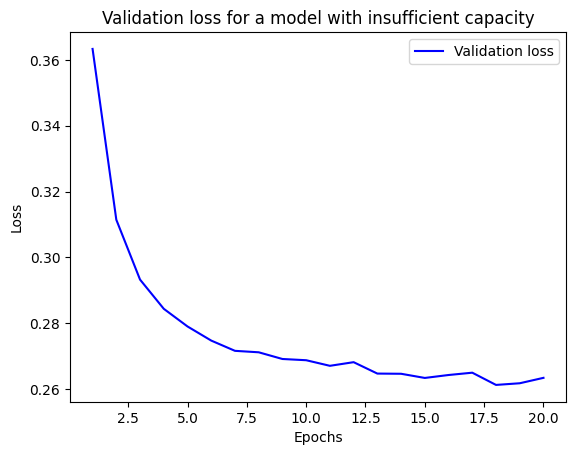

In [11]:
import matplotlib.pyplot as plt

val_loss = history_small_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with insufficient capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [12]:
model = keras.Sequential(
    [
        layers.Dense(128, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_large_model = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9040 - loss: 0.3398 - val_accuracy: 0.9491 - val_loss: 0.1775
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9555 - loss: 0.1460 - val_accuracy: 0.9638 - val_loss: 0.1254
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9695 - loss: 0.1013 - val_accuracy: 0.9613 - val_loss: 0.1236
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9770 - loss: 0.0760 - val_accuracy: 0.9713 - val_loss: 0.0975
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9815 - loss: 0.0595 - val_accuracy: 0.9751 - val_loss: 0.0871
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9860 - loss: 0.0469 - val_accuracy: 0.9768 - val_loss: 0.0805
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9879 - loss: 0.0386 - val_accuracy: 0.9764 - val_loss: 0.0853
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9908 - loss: 0.0303 - val_accuracy: 0.

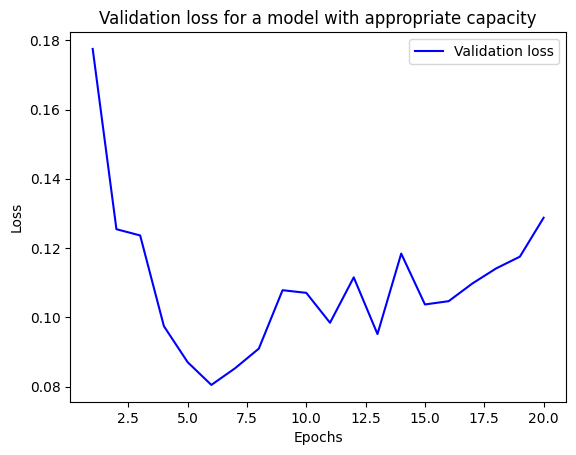

In [16]:
val_loss = history_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with appropriate capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show() # 특정 시점 이후 overfit발생

In [17]:
model = keras.Sequential(
    [
        layers.Dense(2048, activation="relu"),
        layers.Dense(2048, activation="relu"),
        layers.Dense(2048, activation="relu"), #128에 비해 과하게 커졌음! -> overfit이 발생
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_very_large_model = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9272 - loss: 0.2552 - val_accuracy: 0.9642 - val_loss: 0.1448
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9692 - loss: 0.1156 - val_accuracy: 0.9655 - val_loss: 0.1504
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9778 - loss: 0.0869 - val_accuracy: 0.9739 - val_loss: 0.1044
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9828 - loss: 0.0726 - val_accuracy: 0.9762 - val_loss: 0.1150
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9868 - loss: 0.0573 - val_accuracy: 0.9711 - val_loss: 0.1595
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9890 - loss: 0.0493 - val_accuracy: 0.9759 - val_loss: 0.1540
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9913 - loss: 0.0403 - val_accuracy: 0.9731 - val_loss: 0.1715
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9926 - loss: 0.0329 - 

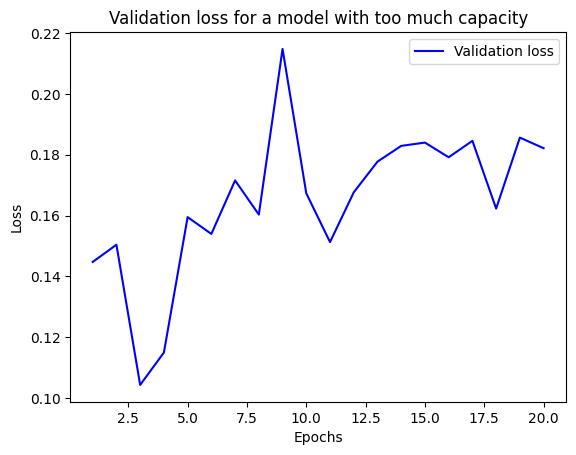

In [18]:
val_loss = history_very_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with too much capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

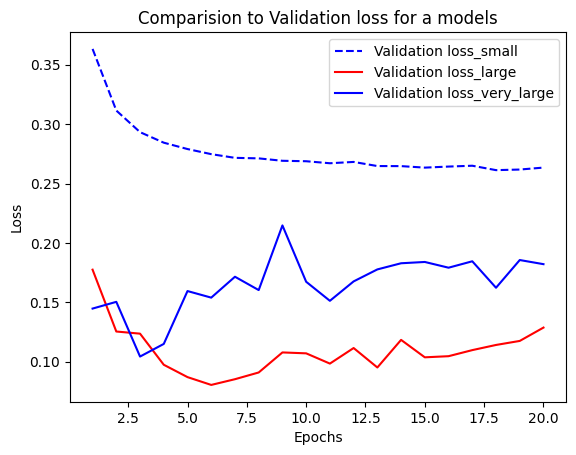

In [21]:
val_loss = history_small_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b--", label="Validation loss_small")

val_loss = history_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "r-", label="Validation loss_large")

val_loss = history_very_large_model.history["val_loss"]
plt.plot(epochs, val_loss, "b-", label="Validation loss_very_large")
plt.title("Comparision to Validation loss for a models")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Improving generalization

#### Dataset curation

#### Feature engineering

#### Using early stopping

#### Regularizing your model

##### Reducing the network's size

In [22]:
from keras.datasets import imdb

(train_data, train_labels), _ = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

train_data = vectorize_sequences(train_data)

model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_original = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.7689 - loss: 0.5632 - val_accuracy: 0.8501 - val_loss: 0.4487
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8853 - loss: 0.3689 - val_accuracy: 0.8808 - val_loss: 0.3418
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9101 - loss: 0.2773 - val_accuracy: 0.8878 - val_loss: 0.2976
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9277 - loss: 0.2235 - val_accuracy: 0.8900 - val_loss: 0.2793
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9376 - loss: 0.1888 - val_accuracy: 0.8873 - val_loss: 0.2792
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9494 - loss: 0.1604 - val_accuracy: 0.8890 - val_loss: 0.2780
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9549 - loss: 0.1401 - val_accuracy: 0.8873 - val_loss: 0.2825
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accurac

In [23]:
model = keras.Sequential(
    [
        layers.Dense(4, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_smaller_model = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.7623 - loss: 0.5700 - val_accuracy: 0.8536 - val_loss: 0.4656
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8891 - loss: 0.3910 - val_accuracy: 0.8810 - val_loss: 0.3684
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9117 - loss: 0.3026 - val_accuracy: 0.8867 - val_loss: 0.3205
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9265 - loss: 0.2487 - val_accuracy: 0.8892 - val_loss: 0.2952
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9361 - loss: 0.2117 - val_accuracy: 0.8896 - val_loss: 0.2836
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9449 - loss: 0.1843 - val_accuracy: 0.8869 - val_loss: 0.2820
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9526 - loss: 0.1636 - val_accuracy: 0.8845 - val_loss: 0.2848
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9596 - loss: 0.1455 - val_accuracy: 0.8899 - v

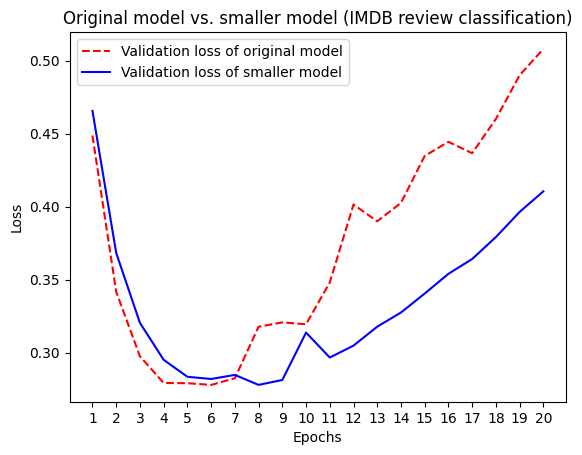

In [24]:
original_val_loss = history_original.history["val_loss"]
smaller_model_val_loss = history_smaller_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    smaller_model_val_loss,
    "b-",
    label="Validation loss of smaller model",
)
plt.title("Original model vs. smaller model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

In [25]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_larger_model = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.7436 - loss: 0.5487 - val_accuracy: 0.8733 - val_loss: 0.3263
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8701 - loss: 0.3171 - val_accuracy: 0.8853 - val_loss: 0.2765
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9040 - loss: 0.2418 - val_accuracy: 0.8840 - val_loss: 0.2787
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9322 - loss: 0.1775 - val_accuracy: 0.8155 - val_loss: 0.4848
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9485 - loss: 0.1351 - val_accuracy: 0.8294 - val_loss: 0.4702
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9597 - loss: 0.1190 - val_accuracy: 0.8872 - val_loss: 0.3194
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9705 - loss: 0.0902 - val_accuracy: 0.8866 - val_loss: 0.3301
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9763 - loss: 0.0797 - val_accuracy: 0.8842 - v

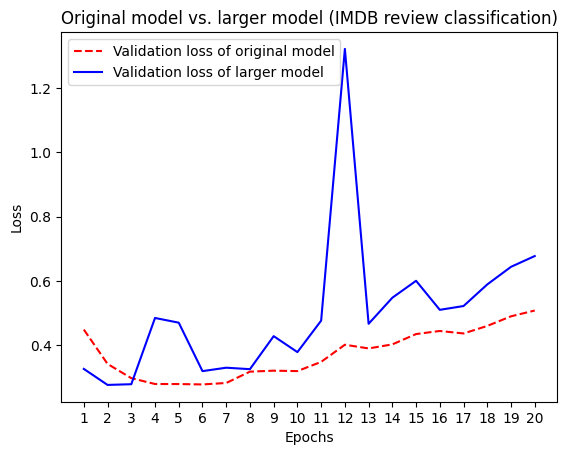

In [26]:
original_val_loss = history_original.history["val_loss"]
larger_model_val_loss = history_larger_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    larger_model_val_loss,
    "b-",
    label="Validation loss of larger model",
)
plt.title("Original model vs. larger model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

##### Adding weight regularization

In [27]:
from keras.regularizers import l2

model = keras.Sequential(
    [
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_l2_reg = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.7739 - loss: 0.6110 - val_accuracy: 0.8647 - val_loss: 0.4798
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8889 - loss: 0.4125 - val_accuracy: 0.8769 - val_loss: 0.4082
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9129 - loss: 0.3407 - val_accuracy: 0.8866 - val_loss: 0.3719
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9234 - loss: 0.3040 - val_accuracy: 0.8784 - val_loss: 0.3791
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9296 - loss: 0.2845 - val_accuracy: 0.8629 - val_loss: 0.4135
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9379 - loss: 0.2652 - val_accuracy: 0.8847 - val_loss: 0.3629
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9401 - loss: 0.2582 - val_accuracy: 0.8849 - val_loss: 0.3706
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9448 - loss: 0.2490 - val_accuracy: 0.8674 - v

이 코드는 케라스(Keras)를 사용하여 L2 규제(regularization)가 적용된 신경망 모델을 정의하고 훈련하는 과정입니다. L2 규제는 모델의 과적합(overfitting)을 줄이는 데 사용됩니다. 구체적으로 살펴보면 다음과 같습니다:

L2 규제 임포트: from keras.regularizers import l2 라인을 통해 L2 규제 함수를 가져옵니다.
모델 정의: keras.Sequential을 사용하여 순차적인 모델을 생성합니다. 이 모델은 세 개의 Dense (완전 연결) 레이어로 구성됩니다.
첫 번째와 두 번째 Dense 레이어는 각각 16개의 유닛(뉴런)을 가지며, 활성화 함수로 relu를 사용합니다. 중요한 점은 kernel_regularizer=l2(0.002)를 사용하여 가중치에 L2 규제를 적용한다는 것입니다. 이는 가중치 값이 너무 커지는 것을 방지하여 모델의 복잡성을 제한하고 과적합을 줄이는 데 도움을 줍니다.
마지막 Dense 레이어는 1개의 유닛을 가지며, sigmoid 활성화 함수를 사용하여 이진 분류(0 또는 1)를 수행합니다.
모델 컴파일: model.compile을 사용하여 모델의 훈련 방식을 설정합니다.

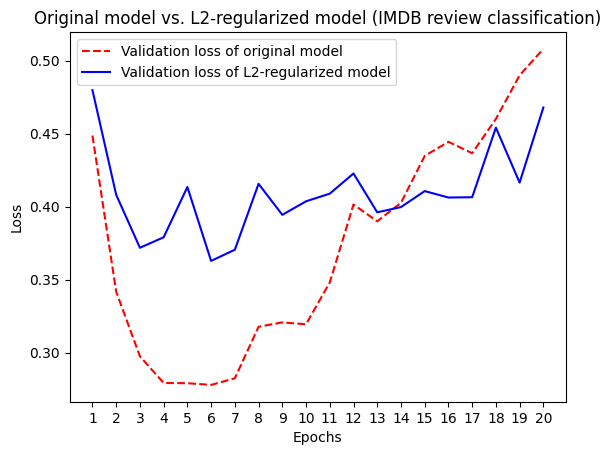

In [28]:
original_val_loss = history_original.history["val_loss"]
l2_val_loss = history_l2_reg.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    l2_val_loss,
    "b-",
    label="Validation loss of L2-regularized model",
)
plt.title(
    "Original model vs. L2-regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

In [29]:
from keras import regularizers

regularizers.l1(0.001)
regularizers.l1_l2(l1=0.001, l2=0.001)

##### Adding dropout

In [30]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_dropout = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.6178 - loss: 0.6514 - val_accuracy: 0.8427 - val_loss: 0.5740
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7550 - loss: 0.5428 - val_accuracy: 0.8671 - val_loss: 0.4668
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8168 - loss: 0.4631 - val_accuracy: 0.8791 - val_loss: 0.3818
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8519 - loss: 0.3987 - val_accuracy: 0.8828 - val_loss: 0.3301
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8813 - loss: 0.3457 - val_accuracy: 0.8852 - val_loss: 0.3076
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8993 - loss: 0.3011 - val_accuracy: 0.8885 - val_loss: 0.2856
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9164 - loss: 0.2661 - val_accuracy: 0.8906 - val_loss: 0.2777
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9248 - loss: 0.2327 - val_accuracy: 0.8910 - 

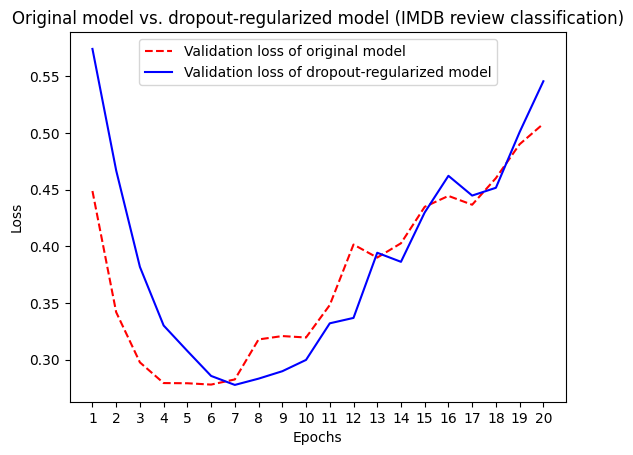

In [31]:
original_val_loss = history_original.history["val_loss"]
dropout_val_loss = history_dropout.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    dropout_val_loss,
    "b-",
    label="Validation loss of dropout-regularized model",
)
plt.title(
    "Original model vs. dropout-regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

이 코드는 두 가지 모델의 검증 손실(validation loss)을 시각적으로 비교합니다. 하나는 원본 모델이고, 다른 하나는 드롭아웃 규제(dropout regularization)가 적용된 모델입니다.

original_val_loss와 dropout_val_loss 변수에는 각 모델의 훈련 기록에서 얻은 검증 손실 값이 저장됩니다.
epochs = range(1, 21)는 x축에 표시될 에포크(훈련 반복 횟수)를 1부터 20까지 설정합니다.
plt.plot 함수를 사용하여 두 모델의 검증 손실을 그래프로 그립니다. 원본 모델은 빨간색 점선(r--)으로, 드롭아웃 규제가 적용된 모델은 파란색 실선(b-)으로 표시됩니다.
그래프의 제목은 'Original model vs. dropout-regularized model (IMDB review classification)'으로 설정되어, IMDB 영화 리뷰 분류 태스크에서 두 모델의 성능을 비교함을 나타냅니다.
x축은 'Epochs', y축은 'Loss'로 레이블이 지정되며, x축 눈금은 에포크 수에 맞게 설정됩니다.
plt.legend()를 통해 각 선이 어떤 모델을 나타내는지 범례를 표시하고, plt.show()로 최종 그래프를 출력합니다.
이 그래프는 드롭아웃이 과적합(overfitting)을 얼마나 효과적으로 줄여 검증 손실을 안정화하는지 보여주는 데 사용됩니다.

드롭아웃(Dropout)은 딥러닝 모델이 훈련 과정에서 데이터의 특정 특징(feature)에 지나치게 의존하는 것을 막고, 과대적합(Overfitting)을 방지하기 위해 사용하는 대표적인 규제(Regularization) 기법입니다.
1. 작동 원리훈련(Training)할 때, 매 에포크(Epoch)나 배치(Batch)마다 무작위로 일정 비율($p$)의 뉴런(노드)을 끄고(0으로 만듦) 남은 뉴런들로만 순전파와 역전파를 진행합니다.동전 던지기 방식: 예를 들어 드롭아웃 비율을 0.5로 설정하면, 훈련 시 각 뉴런은 50% 확률로 참가하고 50% 확률로 쉬게 됩니다.테스트/평가 시(Inference): 드롭아웃을 적용하지 않고 모든 뉴런을 활성화하여 예측합니다. (대신 훈련 시와 출력 스케일을 맞추는 처리가 자동으로 들어갑니다.)
2. 왜 성능이 좋아질까? (핵심 효과)뉴런 간의 '동조(Co-adaptation)' 방지특정 뉴런 몇 개가 전적으로 예측을 주도하거나, 특정 뉴런들끼리 뭉쳐서 편법으로 답을 맞추는 현상을 막습니다.다른 뉴런이 언제 꺼질지 모르기 때문에, 각 뉴런은 독자적이고 유용한 특징을 학습해야 합니다.앙상블(Ensemble) 효과매 걸음마다 서로 다른 조합의 무작위 신경망을 훈련시키는 셈이 됩니다.수많은 서로 다른 소형 모델들의 예측을 평균 내는 앙상블 기법과 비슷한 효과를 내어 general한(일반화된) 성능이 높아집니다.

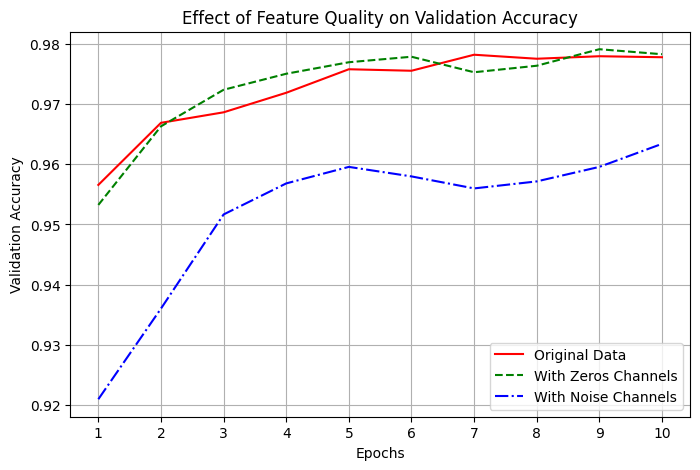

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras.datasets import mnist

# 1. MNIST 데이터 로드 및 전처리
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28)).astype("float32") / 255

# 2. 파생 데이터셋 생성 (Noise 채널 및 Zero 채널 추가)
np.random.seed(42) # 결과 재현성을 위한 고정
train_images_with_noise = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1
)
train_images_with_zeros = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1
)

# 3. 모델 생성 함수 정의
def get_model():
    model = keras.Sequential([
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# 4. 각 조건별 모델 학습
# A. Original Data
model_orig = get_model()
history_orig = model_orig.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2, verbose=0
)

# B. Zeros Channel Added
model_zeros = get_model()
history_zeros = model_zeros.fit(
    train_images_with_zeros, train_labels, epochs=10, batch_size=128, validation_split=0.2, verbose=0
)

# C. Noise Channel Added
model_noise = get_model()
history_noise = model_noise.fit(
    train_images_with_noise, train_labels, epochs=10, batch_size=128, validation_split=0.2, verbose=0
)

# 5. 결과 시각화
epochs = range(1, 11)
plt.figure(figsize=(8, 5))

plt.plot(epochs, history_orig.history["val_accuracy"], "r-", label="Original Data")
plt.plot(epochs, history_zeros.history["val_accuracy"], "g--", label="With Zeros Channels")
plt.plot(epochs, history_noise.history["val_accuracy"], "b-.", label="With Noise Channels")

plt.title("Effect of Feature Quality on Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.show()

1. 학습률(Learning Rate) 수정 및 모델 실패 시점 확인
학습률이 너무 큰 경우(learning_rate=10.0, 손실 발산/NaN)와 너무 작은 경우(learning_rate=1e-7, 학습 정체)를 설정하여 학습 경과를 비교합니다.

In [39]:
import keras
from keras import layers
from keras.datasets import mnist

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28)).astype("float32") / 255

# 1) 학습률이 너무 큰 경우 (발산)
model_high_lr = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])
model_high_lr.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=10.0), # 과도하게 큰 학습률
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
print("--- [Too High Learning Rate (10.0)] ---")
model_high_lr.fit(train_images, train_labels, epochs=5, batch_size=128, validation_split=0.2)

# 2) 학습률이 너무 작은 경우 (학습 정체)
model_low_lr = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])
model_low_lr.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-7), # 지나치게 작은 학습률
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
print("\n--- [Too Low Learning Rate (1e-7)] ---")
model_low_lr.fit(train_images, train_labels, epochs=5, batch_size=128, validation_split=0.2)

--- [Too High Learning Rate (10.0)] ---
Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1034 - loss: 14.4186 - val_accuracy: 0.1081 - val_loss: 14.3760
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1035 - loss: 14.4499 - val_accuracy: 0.1081 - val_loss: 14.3760
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1035 - loss: 14.4499 - val_accuracy: 0.1081 - val_loss: 14.3760
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1035 - loss: 14.4499 - val_accuracy: 0.1081 - val_loss: 14.3760
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1035 - loss: 14.4499 - val_accuracy: 0.1081 - val_loss: 14.3760

--- [Too Low Learning Rate (1e-7)] ---
Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1343 - loss: 2.3315 - val_accuracy: 0.1416 - val_loss: 2.3312
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1396 - loss: 2.3222 - val_accuracy: 0.1478 - val_loss: 2.3218
Epoch 3/5
375/375 ━━━

2. 용량(Capacity)에 따른 모델 검증 손실 비교
은닉층 유닛 수를 적게(16개, Low Capacity) 설정한 모델과 크게(1024개, High Capacity) 설정한 모델의 과대적합(Overfitting) 정도를 비교합니다.

In [40]:
import keras
from keras import layers
from keras.datasets import mnist

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28)).astype("float32") / 255

# 1) 용량이 작은 모델 (Low Capacity)
model_small = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(10, activation="softmax")
])
model_small.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
print("--- [Small Model (16 units)] ---")
history_small = model_small.fit(train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2)

# 2) 용량이 큰 모델 (High Capacity)
model_large = keras.Sequential([
    layers.Dense(1024, activation="relu"),
    layers.Dense(10, activation="softmax")
])
model_large.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
print("\n--- [Large Model (1024 units)] ---")
history_large = model_large.fit(train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2)

--- [Small Model (16 units)] ---
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8258 - loss: 0.6814 - val_accuracy: 0.9042 - val_loss: 0.3468
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9081 - loss: 0.3278 - val_accuracy: 0.9199 - val_loss: 0.2812
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9193 - loss: 0.2847 - val_accuracy: 0.9252 - val_loss: 0.2607
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9260 - loss: 0.2605 - val_accuracy: 0.9284 - val_loss: 0.2465
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9304 - loss: 0.2434 - val_accuracy: 0.9336 - val_loss: 0.2322
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9345 - loss: 0.2311 - val_accuracy: 0.9342 - val_loss: 0.2287
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9377 - loss: 0.2209 - val_accuracy: 0.9371 - val_loss: 0.2224
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9405 

3. 원본 모델 vs 드롭아웃(Dropout) 적용 모델 비교
은닉층 뒤에 Dropout 레이어를 추가하여 과대적합이 억제되고 검증 손실이 안정화되는지 확인합니다.

In [41]:
import keras
from keras import layers
from keras.datasets import mnist

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28)).astype("float32") / 255

# 1) 원본 모델 (Dropout 없음)
model_normal = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])
model_normal.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
print("--- [Original Model Without Dropout] ---")
model_normal.fit(train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2)

# 2) Dropout 적용 모델
model_dropout = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.5), # 50% 유닛 드롭아웃 적용
    layers.Dense(10, activation="softmax")
])
model_dropout.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
print("\n--- [Model With Dropout (0.5)] ---")
model_dropout.fit(train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2)

--- [Original Model Without Dropout] ---
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9153 - loss: 0.2946 - val_accuracy: 0.9517 - val_loss: 0.1752
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9638 - loss: 0.1237 - val_accuracy: 0.9661 - val_loss: 0.1158
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9763 - loss: 0.0813 - val_accuracy: 0.9695 - val_loss: 0.0986
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9831 - loss: 0.0582 - val_accuracy: 0.9764 - val_loss: 0.0811
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9871 - loss: 0.0431 - val_accuracy: 0.9737 - val_loss: 0.0928
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9906 - loss: 0.0325 - val_accuracy: 0.9763 - val_loss: 0.0779
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9934 - loss: 0.0239 - val_accuracy: 0.9786 - val_loss: 0.0740
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy:

4. 은닉층 없는 로지스틱 회귀(Logistic Regression) 구현
중간 은닉층을 제거하고 입력 데이터에서 바로 Softmax 출력층으로 연결하여 다중 클래스 로지스틱 회귀 모델을 구축합니다.

In [42]:
import keras
from keras import layers
from keras.datasets import mnist

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28)).astype("float32") / 255

# 은닉층 없이 입력층 -> 바로 출력층 (Softmax)
model_lr = keras.Sequential([
    layers.Dense(10, activation="softmax") # 은닉층 없음
])

model_lr.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("--- [Multi-class Logistic Regression Model] ---")
model_lr.fit(train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2)

--- [Multi-class Logistic Regression Model] ---
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8317 - loss: 0.6713 - val_accuracy: 0.9028 - val_loss: 0.3646
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9020 - loss: 0.3551 - val_accuracy: 0.9130 - val_loss: 0.3129
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9117 - loss: 0.3188 - val_accuracy: 0.9199 - val_loss: 0.2938
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9159 - loss: 0.3024 - val_accuracy: 0.9210 - val_loss: 0.2856
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9184 - loss: 0.2925 - val_accuracy: 0.9228 - val_loss: 0.2782
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9199 - loss: 0.2857 - val_accuracy: 0.9251 - val_loss: 0.2758
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9217 - loss: 0.2810 - val_accuracy: 0.9248 - val_loss: 0.2742
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - ac

5. 원-핫 인코딩(One-Hot Encoded) 레이블 사용
정수 형태의 레이블을 to_categorical을 통해 원-핫 인코딩 벡터로 바꾸고, 손실 함수를 categorical_crossentropy로 변경하여 학습합니다.

In [43]:
import keras
from keras import layers
from keras.datasets import mnist
from keras.utils import to_categorical

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28)).astype("float32") / 255

# 1. 정수 레이블(0~9)을 원-핫 인코딩 벡터로 변환
train_labels_one_hot = to_categorical(train_labels)

# 2. 모델 정의
model_one_hot = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# 3. 손실 함수를 categorical_crossentropy로 설정
model_one_hot.compile(
    optimizer="rmsprop",
    loss="categorical_crossentropy", # 원-핫 레이블용 손실 함수
    metrics=["accuracy"]
)

print("--- [Model with One-Hot Encoded Labels] ---")
model_one_hot.fit(train_images, train_labels_one_hot, epochs=10, batch_size=128, validation_split=0.2)

--- [Model with One-Hot Encoded Labels] ---
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9175 - loss: 0.2926 - val_accuracy: 0.9589 - val_loss: 0.1494
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9638 - loss: 0.1217 - val_accuracy: 0.9628 - val_loss: 0.1281
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9763 - loss: 0.0791 - val_accuracy: 0.9716 - val_loss: 0.0912
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9827 - loss: 0.0577 - val_accuracy: 0.9734 - val_loss: 0.0822
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9875 - loss: 0.0432 - val_accuracy: 0.9748 - val_loss: 0.0810
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9906 - loss: 0.0325 - val_accuracy: 0.9769 - val_loss: 0.0802
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9926 - loss: 0.0252 - val_accuracy: 0.9770 - val_loss: 0.0803
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accura

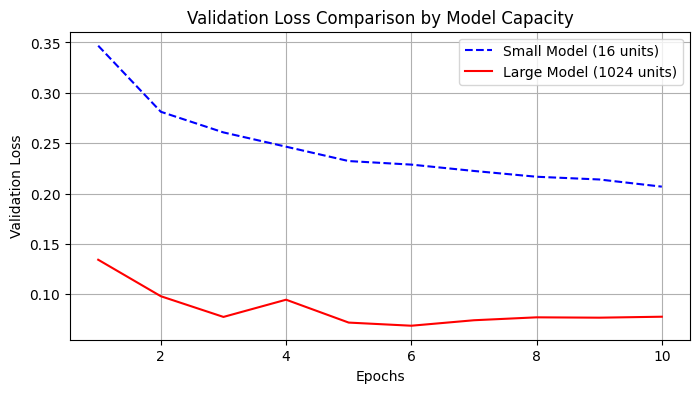

In [45]:
import matplotlib.pyplot as plt

val_loss_small = history_small.history["val_loss"]
val_loss_large = history_large.history["val_loss"]
epochs = range(1, len(val_loss_small) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, val_loss_small, "b--", label="Small Model (16 units)")
plt.plot(epochs, val_loss_large, "r-", label="Large Model (1024 units)")

plt.title("Validation Loss Comparison by Model Capacity")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9142 - loss: 0.2993 - val_accuracy: 0.9558 - val_loss: 0.1551
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9642 - loss: 0.1234 - val_accuracy: 0.9692 - val_loss: 0.1073
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9763 - loss: 0.0801 - val_accuracy: 0.9736 - val_loss: 0.0846
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9835 - loss: 0.0576 - val_accuracy: 0.9746 - val_loss: 0.0815
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9877 - loss: 0.0423 - val_accuracy: 0.9777 - val_loss: 0.0772
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9905 - loss: 0.0321 - val_accuracy: 0.9768 - val_loss: 0.0753
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9932 - loss: 0.0241 - val_accuracy: 0.9803 - val_loss: 0.0705
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9954 - loss: 0.0182 - val_accuracy: 0.

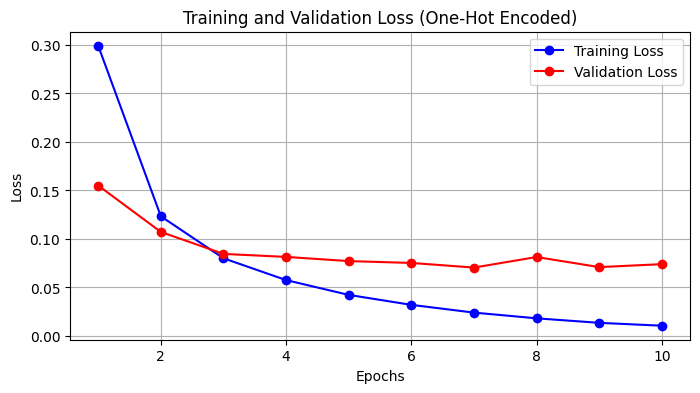

In [51]:
import keras
from keras import layers
from keras.datasets import mnist
from keras.utils import to_categorical
import matplotlib.pyplot as plt

# 1. 데이터 로드 및 전처리
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28)).astype("float32") / 255

# 2. 레이블 원-핫 인코딩 변환
train_labels_one_hot = to_categorical(train_labels)

# 3. 모델 정의 및 categorical_crossentropy 설정
model_one_hot = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])
model_one_hot.compile(
    optimizer="rmsprop",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
history_one_hot = model_one_hot.fit(
    train_images, train_labels_one_hot, epochs=10, batch_size=128, validation_split=0.2, verbose=1
)

# 4. 시각화
train_loss = history_one_hot.history["loss"]
val_loss = history_one_hot.history["val_loss"]
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_loss, "bo-", label="Training Loss")
plt.plot(epochs, val_loss, "ro-", label="Validation Loss")
plt.title("Training and Validation Loss (One-Hot Encoded)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()